In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import copy

In [9]:
# 1. Base classes and function definitions

class ShallowReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))

    def forward(self, x): return self.net(x).squeeze()


class DeepReLU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()])
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x).squeeze()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def preprocess_uploaded_data(file_path='features_target.csv', d=21, target_window=30):
    df = pd.read_csv(file_path)
    df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)
    df['Target_Vol'] = df['SP500 30 Day Volatility'].shift(-target_window)

    feature_cols = []
    for i in range(d, 0, -1):
        col_name = f'Return_t-{i}'
        df[col_name] = df['SP500 Log Returns'].shift(i)
        feature_cols.append(col_name)

    df_clean = df.dropna(subset=feature_cols + ['Target_Vol']).copy()
    X = df_clean[feature_cols].values
    y = df_clean['Target_Vol'].values

    n_samples = len(df_clean)
    train_end = int(n_samples * 0.70)
    val_end = int(n_samples * 0.85)

    return X[:train_end], y[:train_end], X[train_end:val_end], y[train_end:val_end], X[val_end:], y[val_end:]


def train_model(model, name, train_loader, val_loader, epochs=300, lr=0.001, patience=15):
    print(f"  -> Training {name} ...")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss, patience_counter = float('inf'), 0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = sum(criterion(model(xb), yb).item() * xb.size(0) for xb, yb in val_loader) / len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss, best_weights, patience_counter = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            patience_counter += 1

        if patience_counter >= patience: break

    model.load_state_dict(best_weights)
    return model

In [10]:
# 2. Core Experiment: Testing approximation robustness under different dimensions

# We define three representative time window dimensions: one week, one month, one quarter
dimensions_to_test = [5, 21, 63]
# Strictly lock the total parameter budget around 20,000
TARGET_W = 20000

shallow_mse_results = []
deep_mse_results = []
criterion_test = nn.MSELoss()

print("Starting the Curse of Dimensionality special test...")

for d in dimensions_to_test:
    print(f"\n==================================================")
    print(f" Testing input dimension d = {d} (sliding window)")
    print(f"==================================================")

    # Reprocess the data for this dimension
    X_train, y_train, X_val, y_val, X_test, y_test = preprocess_uploaded_data(d=d)

    # Convert to Tensor DataLoader
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
        batch_size=64, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)),
        batch_size=64, shuffle=False)
    X_test_t, y_test_t = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)

    # --- Architecture computation (keep parameter count consistent) ---
    # Shallow ReLU: Width adaptive formula H = W / (d + 2)
    shallow_width = int(TARGET_W / (d + 2))
    shallow_net = ShallowReLU(input_dim=d, hidden_dim=shallow_width)
    w_s = count_parameters(shallow_net)

    # Deep ReLU: Fixed hidden layer width to 40, dynamically calculate required layers based on input dimension d
    deep_width = 40
    params_per_hidden = deep_width * deep_width + deep_width
    input_layer_params = d * deep_width + deep_width
    output_layer_params = deep_width * 1 + 1
    num_layers = max(2, int((TARGET_W - input_layer_params - output_layer_params) / params_per_hidden) + 1)

    deep_net = DeepReLU(input_dim=d, hidden_dim=deep_width, num_layers=num_layers)
    w_d = count_parameters(deep_net)

    print(f"  [Arch Alignment] Shallow W: {w_s} | Deep W: {w_d} (Layers: {num_layers})")

    # --- Training and Testing ---
    best_shallow = train_model(shallow_net, "Shallow ReLU", train_loader, val_loader)
    best_deep = train_model(deep_net, "Deep ReLU", train_loader, val_loader)

    best_shallow.eval();
    best_deep.eval()
    with torch.no_grad():
        s_mse = criterion_test(best_shallow(X_test_t), y_test_t).item()
        d_mse = criterion_test(best_deep(X_test_t), y_test_t).item()

    shallow_mse_results.append(s_mse)
    deep_mse_results.append(d_mse)

    print(f"  [Test Results] Shallow MSE: {s_mse:.4f} | Deep MSE: {d_mse:.4f}")

Starting the Curse of Dimensionality special test...

 Testing input dimension d = 5 (sliding window)
  [Arch Alignment] Shallow W: 20000 | Deep W: 19961 (Layers: 13)
  -> Training Shallow ReLU ...
  -> Training Deep ReLU ...
  [Test Results] Shallow MSE: 949.8610 | Deep MSE: 905.6670

 Testing input dimension d = 21 (sliding window)
  [Arch Alignment] Shallow W: 19988 | Deep W: 18961 (Layers: 12)
  -> Training Shallow ReLU ...
  -> Training Deep ReLU ...
  [Test Results] Shallow MSE: 962.9012 | Deep MSE: 898.3611

 Testing input dimension d = 63 (sliding window)
  [Arch Alignment] Shallow W: 19956 | Deep W: 19001 (Layers: 11)
  -> Training Shallow ReLU ...
  -> Training Deep ReLU ...
  [Test Results] Shallow MSE: 998.0110 | Deep MSE: 838.0299



Curse of Dimensionality test completed! Chart saved as 'curse_of_dimensionality_plot.png'.


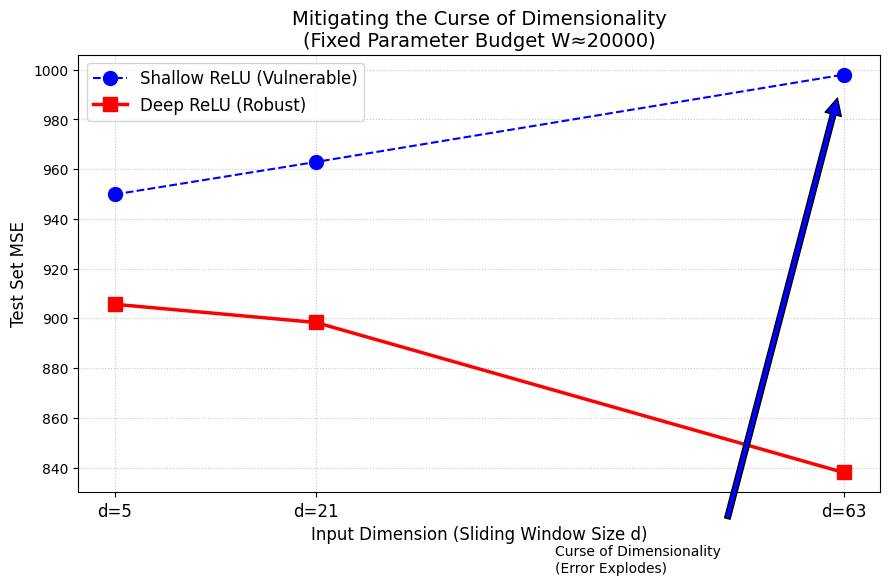

In [11]:
# 3. Plotting the "Mitigating Curse of Dimensionality" visual comparison

plt.figure(figsize=(9, 6))
plt.plot(dimensions_to_test, shallow_mse_results, marker='o', markersize=10, linestyle='--', color='blue',
         label='Shallow ReLU (Vulnerable)')
plt.plot(dimensions_to_test, deep_mse_results, marker='s', markersize=10, linewidth=2.5, color='red',
         label='Deep ReLU (Robust)')

plt.xticks(dimensions_to_test, labels=[f'd={d}' for d in dimensions_to_test], fontsize=12)
plt.xlabel('Input Dimension (Sliding Window Size d)', fontsize=12)
plt.ylabel('Test Set MSE', fontsize=12)
plt.title('Mitigating the Curse of Dimensionality\n(Fixed Parameter Budget W≈20000)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Annotate trend
plt.annotate('Curse of Dimensionality\n(Error Explodes)', xy=(63, shallow_mse_results[-1]),
             xytext=(40, shallow_mse_results[-1] - 200),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.tight_layout()
plt.savefig('curse_of_dimensionality_plot.png', dpi=300)
print("\nCurse of Dimensionality test completed! Chart saved as 'curse_of_dimensionality_plot.png'.")